In [38]:
# Import the important library which i need in datasets
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [39]:
#Load the data
df=pd.read_csv(r'C:\Users\DELL\AppData\Local\Temp\18989416-edc1-48b0-ad09-e48c2c38971c_archive (1).zip.71c\usa_housing_kaggle.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [40]:
#Check the null value in datasets
df.isnull().sum()

Price           0
Bedrooms        0
Bathrooms       0
SquareFeet      0
YearBuilt       0
GarageSpaces    0
LotSize         0
ZipCode         0
CrimeRate       0
SchoolRating    0
dtype: int64

In [41]:
#Check the info of the datasets
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB


In [42]:
# Check the describe like min max or etc
df.describe()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,522761.916667,2.966667,2.464000,3052.75000,1962.616667,1.513333,1.062200,54324.770000,49.324033,5.096667
std,256922.348275,1.451175,0.886184,1194.97144,36.005431,1.116832,0.543896,24718.938552,28.833220,2.674165
min,112666.000000,1.000000,1.000000,840.00000,1902.000000,0.000000,0.110000,10163.000000,0.190000,1.000000
25%,299936.500000,2.000000,1.700000,2053.50000,1931.750000,1.000000,0.570000,34175.000000,22.547500,3.000000
50%,505806.500000,3.000000,2.400000,3127.00000,1961.000000,1.000000,1.085000,54896.500000,49.970000,5.000000
75%,744603.750000,4.000000,3.200000,4081.00000,1994.000000,3.000000,1.482500,74108.000000,74.402500,8.000000
max,999684.000000,5.000000,4.000000,4997.00000,2022.000000,3.000000,2.000000,99881.000000,99.710000,9.000000


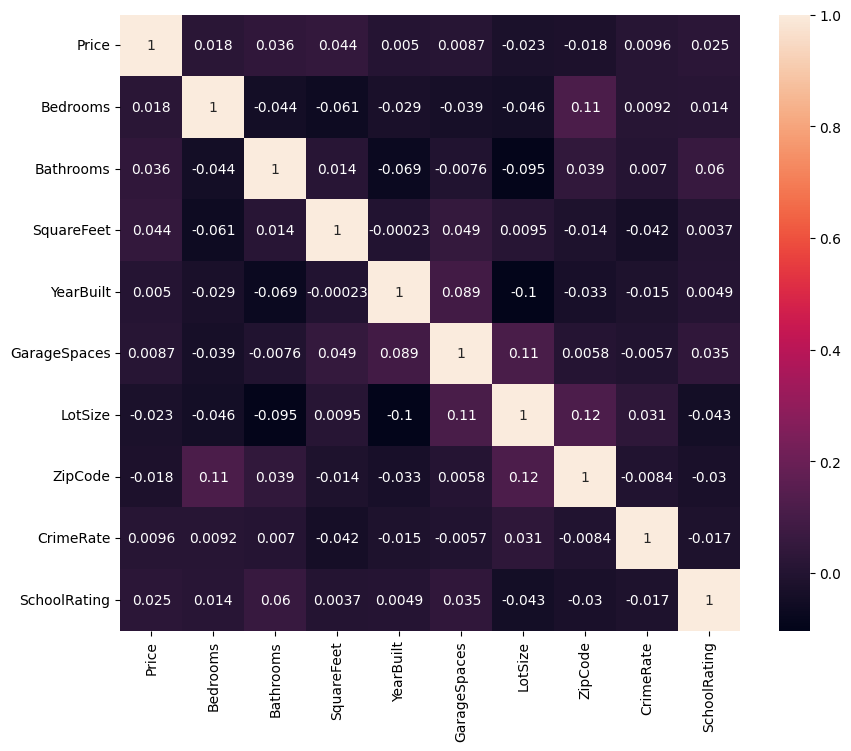

In [43]:
''' Check the correlation map of the price column with other column
You can see the lot size and zip code id negative they are two solution make
it better or remove the column i remove the column of lot size and make 
the good column of zip code after that see again

'''
corr_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True)
plt.show()

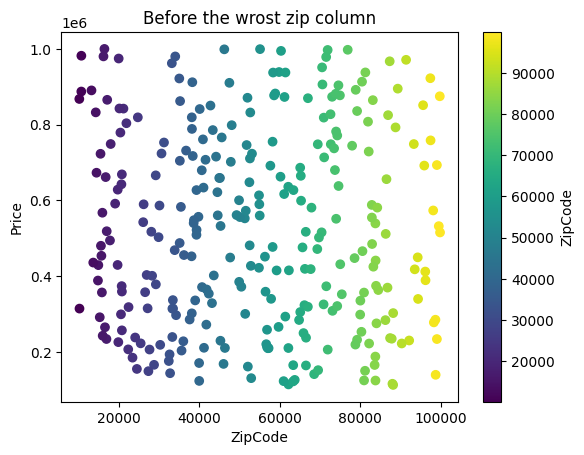

In [44]:
# See the Correlataion every scatter move here and there not the good order
plt.scatter(df['ZipCode'],df['Price'],c=df['ZipCode'])
plt.xlabel('ZipCode')
plt.ylabel('Price')
plt.title('Before the wrost zip column')
plt.colorbar(label="ZipCode")
plt.show()

In [45]:
# Zip code is negative to price because the zip code is importand but they all are different 
df['ZipCode'].corr(df['Price'])

np.float64(-0.01827989504961794)

In [46]:
'''I do the zip code group by afeter that exact same zip code
price make the means or at the end make the another 
column name is the zipencoded
'''
df['ZipCode']=df['ZipCode'].astype(str)
zip_avg_price=df.groupby('ZipCode')['Price'].mean()
df['ZipEncoded']=df['ZipCode'].map(zip_avg_price)


In [47]:
# Remove the Zip code or Lot size column or see the dataframe again 
df=df.drop(columns=['ZipCode','LotSize'])
df.head()


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,CrimeRate,SchoolRating,ZipEncoded
0,221958,1,1.9,4827,1979,2,48.60,5,221958.0
1,771155,2,2.0,1035,1987,2,92.03,9,771155.0
2,231932,1,3.0,2769,1982,1,52.08,3,231932.0
3,465838,3,3.3,2708,1907,3,61.65,1,465838.0
4,359178,4,3.4,1175,1994,2,15.66,4,359178.0


In [48]:
# Now its zip encoded is prefect nearly to 1
df['ZipEncoded'].corr(df['Price'])

np.float64(0.9999999999999999)

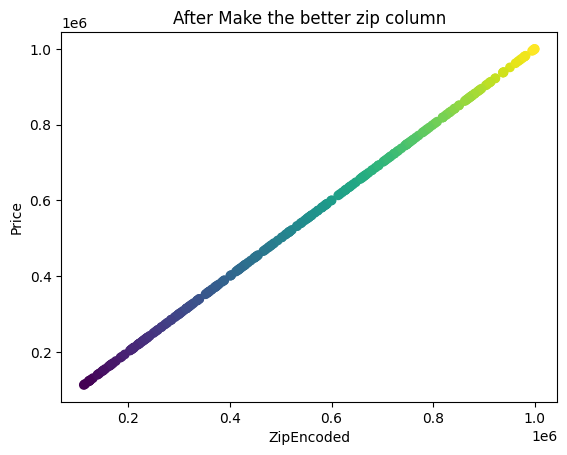

In [49]:
# Now scatter plot also best exact match
plt.scatter(df['ZipEncoded'],df['Price'],c=df['ZipEncoded'])
plt.xlabel('ZipEncoded')
plt.ylabel('Price')
plt.title('After Make the better zip column')
plt.show()

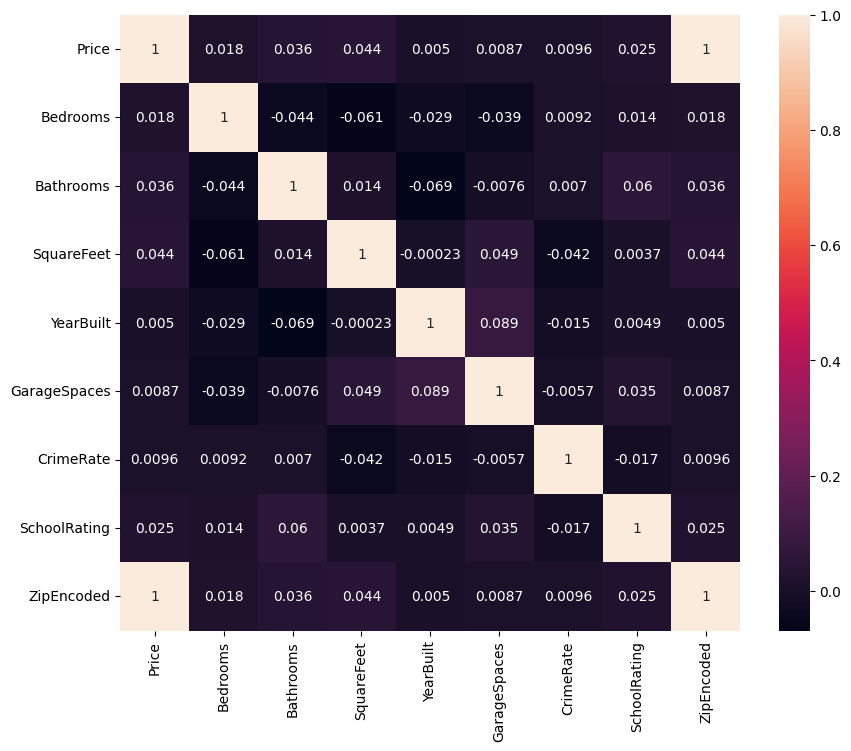

In [50]:
# See the correlation map again and now is best

corr_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True)
plt.show()

In [51]:
X=df.drop('Price',axis=1)
y=df['Price']

In [52]:
# Use standard scaler make the value +1.-1
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [53]:
# do train test split after training the data check the prediction
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.33,random_state=42)

Linear Regression

In [54]:
LE=LinearRegression()
LE.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_pred=LE.predict(X_test)
y_pred

array([642335., 580671., 994498., 237337., 547600., 637833., 209556.,
       819064., 744167., 731347., 293075., 449457., 502690., 184654.,
       827270., 121959., 411955., 785440., 589570., 219176., 560337.,
       336584., 913168., 325281., 567281., 552366., 967055., 862002.,
       572525., 314283., 429365., 745914., 586232., 299041., 717075.,
       364712., 832180., 296769., 691723., 903591., 723587., 704365.,
       151663., 339931., 922352., 798361., 937437., 979989., 532315.,
       693128., 835716., 451279., 414877., 206530., 758271., 713333.,
       882038., 323165., 143585., 891743., 218451., 370936., 210268.,
       874684., 872838., 447449., 427069., 369536., 573254., 264899.,
       374329., 580754., 161087., 471369., 113986., 122671., 308261.,
       441097., 168148., 978338., 715270., 591234., 887201., 803550.,
       824839., 662332., 402918., 356508., 378167., 621430., 164044.,
       320884., 748531., 890180., 484681., 141090., 511357., 747972.,
       792517.])

In [56]:
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("R2: ",r2_score(y_test,y_pred))

MAE:  1.6815546486112806e-10
MSE:  4.6544032657206e-20
R2:  1.0


KNeighborsRegressor


In [57]:

KNR=KNeighborsRegressor(n_neighbors=5)
KNR.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [58]:
y_pred_Knr=KNR.predict(X_test)
y_pred_Knr

array([689612.6, 424153.2, 914012. , 239503.4, 547733.6, 594566.2,
       398626.8, 784087. , 634547.4, 740361.4, 349595. , 388191.2,
       447574. , 328257. , 948087.2, 200813.6, 437287.6, 879519.4,
       528769.4, 372059.8, 512028.6, 342738. , 851984.4, 477777.6,
       479725.2, 689062.4, 771973.8, 772690. , 526525.8, 438597.2,
       394776.8, 673248.4, 616021.4, 314931.6, 646289.6, 443507. ,
       795862. , 377617.4, 719078.2, 801354.6, 521235. , 538834.6,
       250112.8, 304668.8, 679930.2, 666690.8, 823620.2, 907771.4,
       582860.6, 691405.6, 721753.6, 545810.8, 504262.2, 265586.4,
       786006. , 654385.2, 784834.2, 344020. , 309014.8, 838734. ,
       317101. , 405305.8, 303947.2, 786405.2, 532987.4, 487129.4,
       351780.2, 281951.8, 666668.4, 357364.6, 392908.8, 586109.2,
       299089.4, 522780.2, 273940.2, 311153. , 367543. , 460267.2,
       303288.8, 942546.6, 649931. , 602458. , 710680.8, 605001.2,
       650577. , 586349. , 444145.2, 358047.4, 490839.4, 54194

In [59]:
print("MAE: ",mean_absolute_error(y_test,y_pred_Knr))
print("MSE: ",mean_squared_error(y_test,y_pred_Knr))
print("R2: ",r2_score(y_test,y_pred_Knr))

MAE:  88607.28282828283
MSE:  11957660395.657776
R2:  0.8147785429795352


DecisionTreeRegressor

In [60]:
DTR=DecisionTreeRegressor()
DTR.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [61]:
y_pred_Dtr=DTR.predict(X_test)
y_pred_Dtr

array([661353., 587879., 996942., 239182., 561079., 635822., 210687.,
       818315., 748143., 728776., 291335., 448951., 501896., 187498.,
       831912., 125939., 417824., 788519., 589492., 220151., 556551.,
       335796., 894824., 318969., 556551., 554589., 981691., 864469.,
       582690., 314176., 428947., 748663., 587879., 298286., 722794.,
       363160., 831912., 298286., 686146., 905889., 723094., 710490.,
       150015., 335167., 937291., 819094., 938688., 974371., 539792.,
       686146., 831912., 448951., 421879., 203355., 760890., 701661.,
       881239., 314176., 148984., 894824., 220151., 373109., 210687.,
       877089., 881239., 448951., 428947., 373538., 587879., 265838.,
       373538., 587879., 164820., 468452., 112666., 124300., 305041.,
       431236., 170467., 974371., 710490., 589492., 877089., 818315.,
       818315., 659042., 401648., 356840., 371836., 616588., 164820.,
       318126., 748663., 911774., 487261., 139353., 501896., 748663.,
       788519.])

In [62]:
print("MAE: ",mean_absolute_error(y_test,y_pred_Dtr))
print("MSE: ",mean_squared_error(y_test,y_pred_Dtr))
print("R2: ",r2_score(y_test,y_pred_Dtr))

MAE:  4672.080808080808
MSE:  44706609.63636363
R2:  0.9993075047207145


RandomForestRegressor

In [63]:
Rfr=RandomForestRegressor()
Rfr.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
y_pred_Rfr=Rfr.predict(X_test)
y_pred_Rfr

array([642020.07, 592777.2 , 994706.03, 237380.51, 555542.41, 627518.02,
       208098.32, 814081.62, 749191.83, 729984.7 , 292479.51, 453589.6 ,
       505417.51, 185908.64, 827031.43, 126267.11, 416126.06, 785844.99,
       594528.51, 221698.22, 560262.13, 334738.06, 909561.11, 321630.84,
       560580.12, 556880.25, 974689.05, 869139.33, 576213.88, 319852.22,
       428276.81, 752001.36, 596237.44, 300908.  , 718917.83, 359516.47,
       835233.24, 300753.98, 687516.19, 908878.68, 723149.  , 705636.15,
       151210.05, 334515.88, 919972.04, 798870.14, 939575.4 , 983376.93,
       537824.69, 686544.  , 836587.36, 453526.87, 419608.84, 205738.33,
       758679.69, 710915.5 , 877941.52, 317282.81, 143108.14, 892081.2 ,
       221963.12, 374703.16, 209077.47, 875940.98, 874676.55, 451774.66,
       425149.67, 373569.85, 579150.73, 265181.26, 374930.15, 587612.85,
       169019.05, 472848.39, 118350.16, 123851.97, 307104.14, 437338.64,
       168941.3 , 976865.99, 712661.04, 597281.37, 

In [65]:
print("MAE: ",mean_absolute_error(y_test,y_pred_Rfr))
print("MSE: ",mean_squared_error(y_test,y_pred_Rfr))
print("R2: ",r2_score(y_test,y_pred_Rfr))


MAE:  3341.93525252525
MSE:  18420837.940205008
R2:  0.9997146653835343


MODEL                               R2               |         MAE                              |              MSE
Linear Regression                   1.0              |1.6815546486112806e-10                    | 4.6544032657206e-20
KNeighborsRegressor           0.8147785429795352     |88607.28282828283                         | 11957660395.657776
Decision Tree                 0.9987383931975284     |5724.272727272727                         | 81447721.76767677
Random Forest                 0.9997590068269955     |3109.3289898989847                        | 15558211.056190899

In [66]:

#MODEL                               R2               |         MAE                              |              MSE
#Linear Regression                   1.0              |1.6815546486112806e-10                    | 4.6544032657206e-20
#KNeighborsRegressor           0.8147785429795352     |88607.28282828283                         | 11957660395.657776
#Decision Tree                 0.9987383931975284     |5724.272727272727                         | 81447721.76767677
#Random Forest                 0.9997590068269955     |3109.3289898989847                        | 15558211.056190899


In [67]:
with open ('Random_forest.pkl','wb') as file:
    pickle.dump(Rfr,file)

In [68]:
with open ('house_price_model_DTR.pkl','wb') as file:
    pickle.dump(DTR,file)

In [69]:
with open ('house_price_model_LE.pkl','wb') as file:
    pickle.dump(LE,file)

In [70]:
with open ('house_price_modelKnr.pkl','wb') as file:
    pickle.dump(KNR,file)